<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 2: Language Modelling (Model Evaluation) </h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Evaluating NLP Classification Systems: A Case Study**

Suppose you run a bakery brand called **Sweet Crust Co.**, and you want to automatically monitor what customers are saying about your products on social media. Your team builds a text classification system that scans posts and flags those that mention your baked goods. Before going live, you need to ask: *how do we know if it actually works?*

This is the core challenge of **NLP system evaluation**,and choosing the right metric makes all the difference.

---

### **Intrinsic vs. Extrinsic Evaluation**

There are two broad approaches to measuring how well an NLP system performs:

**Intrinsic evaluation** measures a system's output against a fixed reference — a "gold standard" — independent of any real-world task. Think of it like grading a student's essay against a model answer. A common intrinsic metric for language models is *perplexity*, which captures how surprised a model is by new text. A low perplexity score suggests the model has learned patterns well internally.

**Extrinsic evaluation** measures performance based on how useful the system actually is in a downstream task. Even if a model scores well intrinsically, that doesn't mean it will perform well in the real world. As Hailu et al. (2020) note, extrinsic evaluation focuses on the *impact* of a system's output, not just its internal consistency.

**Example:** A spell-checker might score well on perplexity, but if it keeps autocorrecting technical jargon in medical reports, it's failing at the task that matters.

---

### **The Four Extrinsic Metrics**

When evaluating a classification system, four metrics are especially important:

- **Accuracy**
- **Precision**
- **Recall**
- **F-score**

These are best understood through a **confusion matrix**, which breaks predictions into four categories:

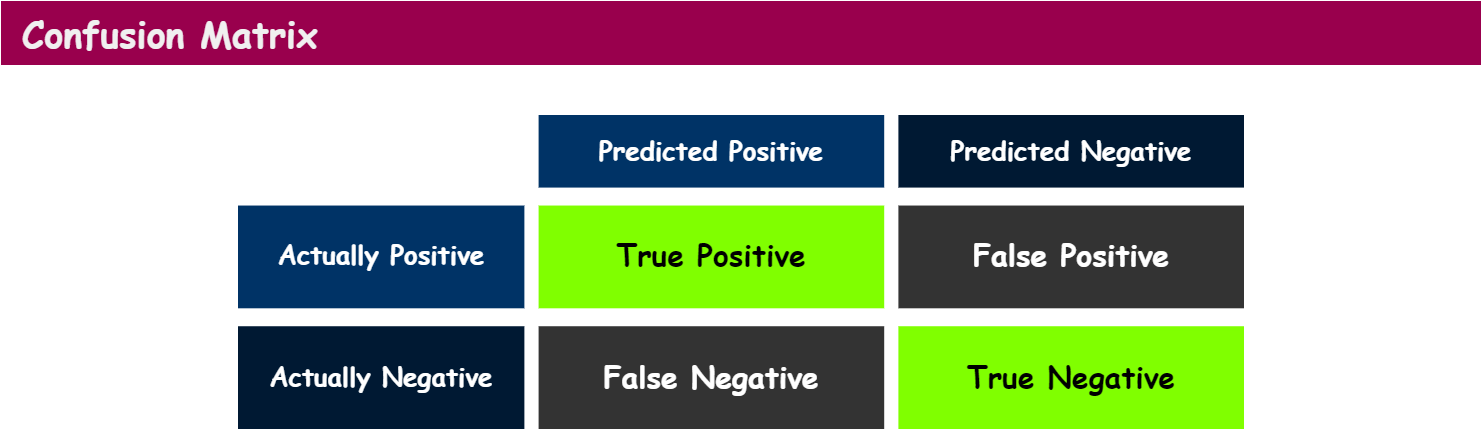

| Metric | Formula | What it asks |
|---|---|---|
| **Accuracy** | (TP + TN) / (TP + FP + TN + FN) | Of all cases, how many did we get right? |
| **Precision** | TP / (TP + FP) | Of what we flagged positive, how many were actually positive? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did we catch? |
| **F-score** | 2 × (P × R) / (P + R) | Balanced harmonic mean of precision and recall |

#### **Equations:**
$$\text{Accuracy} = \frac{\text{True Positive} + \text{True Negative}}{\text{True Positive} + \text{False Positive} + \text{True Negative} + \text{False Negative}}$$

$$\text{Precision} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Positive}}$$

$$\text{Recall} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Negative}}$$

$$\text{F-score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

<br>

---

### **Why Accuracy Alone Can Mislead You**

Consider this scenario for Sweet Crust Co.:

- **1,000,000** social media posts are collected
- Only **100** actually mention the bakery *(gold standard positives)*
- The remaining **999,900** are unrelated *(gold standard negatives)*
- The classifier flags just **1 post** as positive — and it happens to be correct

**Accuracy** = (1 + 999,900) / 1,000,000 ≈ **99.99%**

Sounds great — but the system missed 99 out of 100 relevant posts. It labelled everything as negative and got rewarded for it because relevant posts are so rare.

**Recall** = 1 / (1 + 99) = **0.01** — the system found almost nothing it was supposed to find.

**Precision** = 1 / (1 + 0) = **1.00** — trivially perfect because it only made one positive prediction.

This is the **class imbalance problem**. Accuracy rewards the majority class and masks failure on the minority class — exactly the class you care about.

---

### **Example: Spam Detection**

- 10,000 emails arrive; 200 are spam, 9,800 are legitimate
- The filter flags 180 emails as spam: 150 are truly spam, 30 are not
- It misses 50 actual spam emails

**Accuracy** = (150 + 9,770) / 10,000 = **99.2%** — again, deceptively high.

**Precision** = 150 / (150 + 30) = **83.3%**

**Recall** = 150 / (150 + 50) = **75%**

**F-score** = 2 × (0.833 × 0.75) / (0.833 + 0.75) ≈ **0.789**

---

### **Choosing the Right Metric**

- **High recall matters** when missing a positive is costly — e.g., a cancer screening tool should catch as many cases as possible.
- **High precision matters** when false positives are costly — e.g., a fraud detection system should only act when confident.
- **F-score** is useful when you need a balance between the two.
